Scanning runs_compare ...
Found 4 configuration(s):
  ver25_PrefLID_N8_K8_b20000: 20 seed(s)
  ver2_PrefLID_N5_K5_b20000: 8 seed(s)
  ver6_P2ETG_N5_K5_a2.0: 10 seed(s)
  ver6_P2ETG_N8_K8_a2.0: 5 seed(s)
Found 4 configurations:
  ver25_PrefLID_N8_K8_b20000: 20 seeds
  ver2_PrefLID_N5_K5_b20000: 8 seeds
  ver6_P2ETG_N5_K5_a2.0: 10 seeds
  ver6_P2ETG_N8_K8_a2.0: 5 seeds
Saved: plots/individual_regrets.png


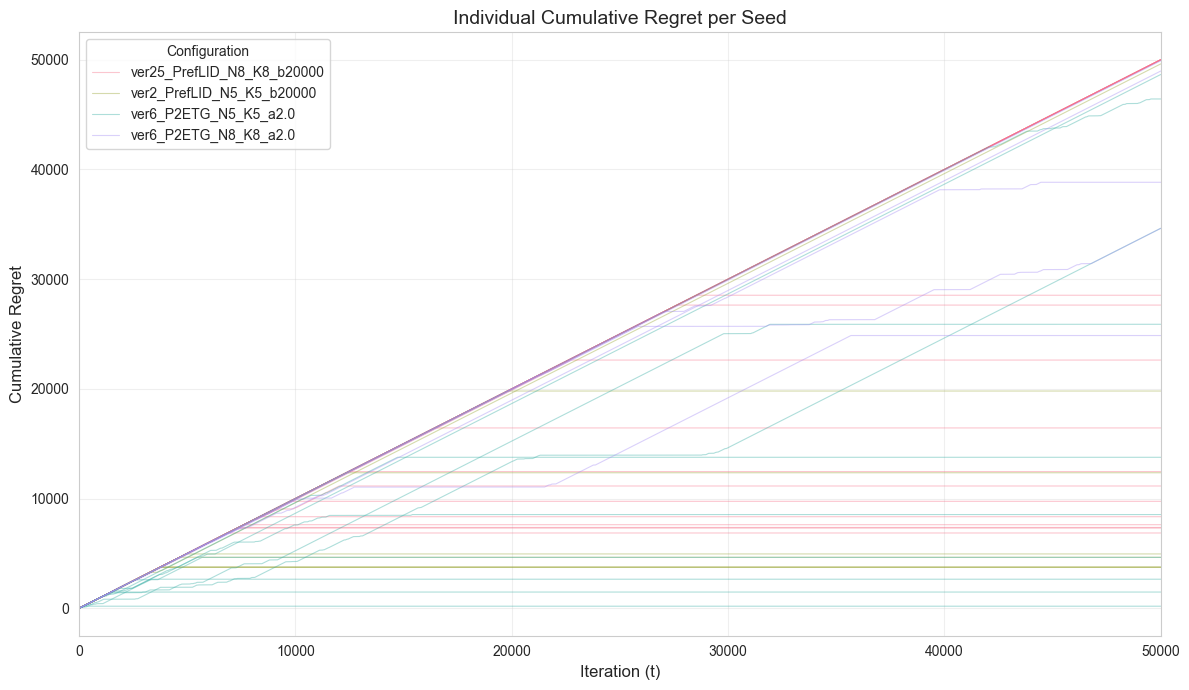

Saved: plots/mean_regret_std.png


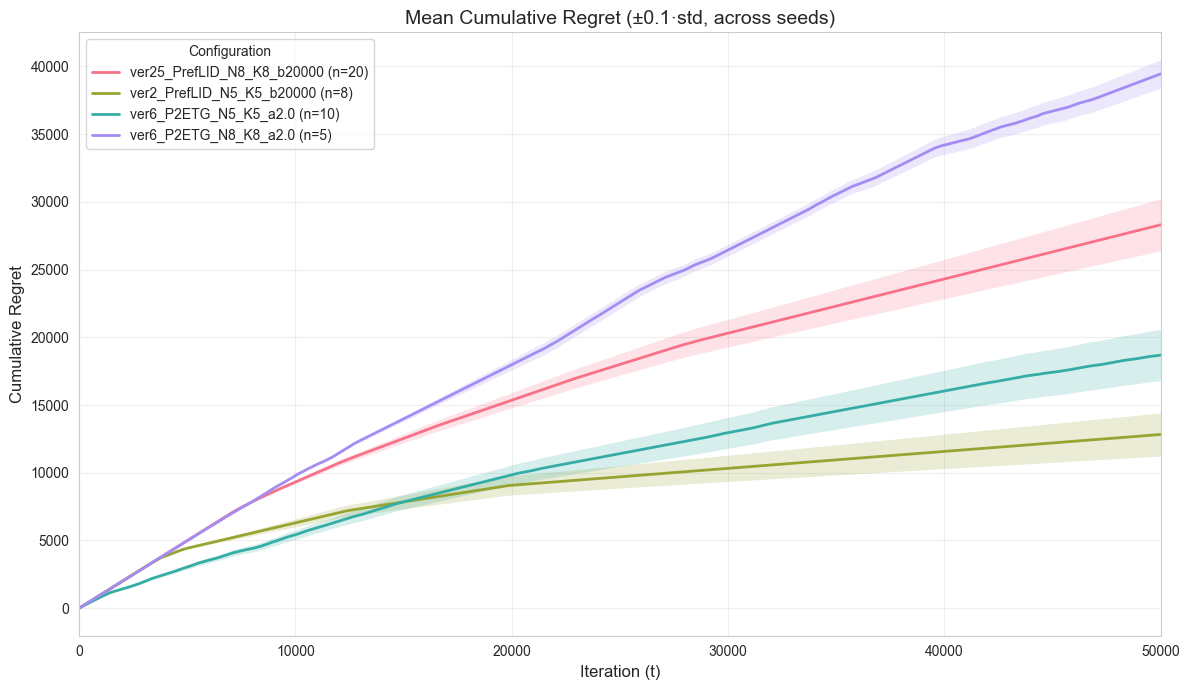

Saved: plots/summary_stats.png


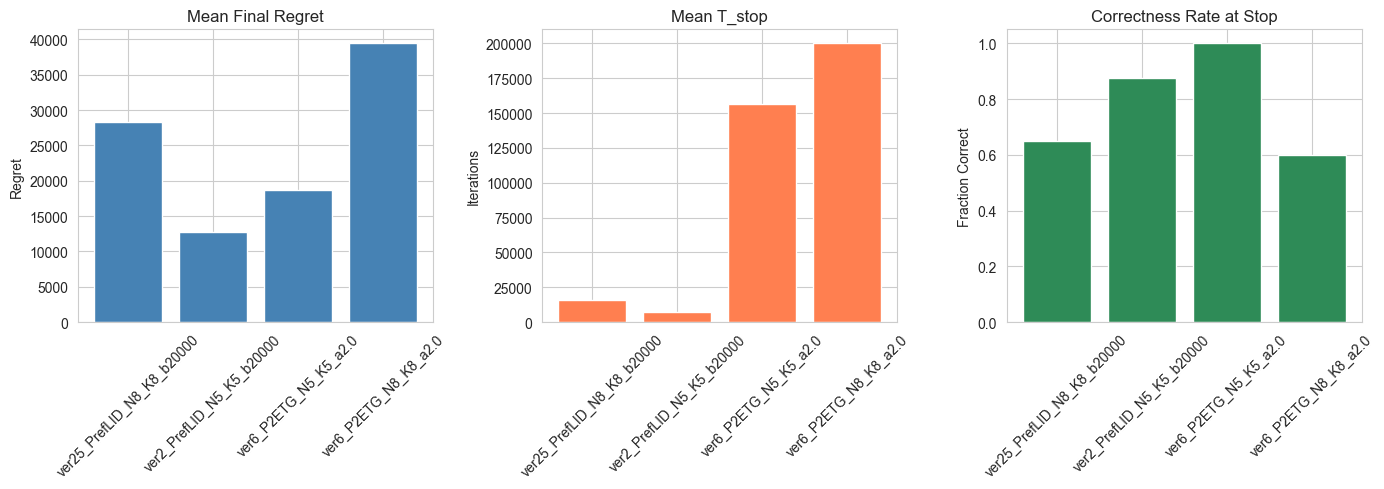

(<Figure size 1400x500 with 3 Axes>,
 array([<Axes: title={'center': 'Mean Final Regret'}, ylabel='Regret'>,
        <Axes: title={'center': 'Mean T_stop'}, ylabel='Iterations'>,
        <Axes: title={'center': 'Correctness Rate at Stop'}, ylabel='Fraction Correct'>],
       dtype=object))

In [11]:
# regret_plotting.py

# import os
# import json
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from pathlib import Path
# import re

from plotting import *

# ---- CONFIGURE THIS ----
BASE_DIR = "runs_compare"   # <-- change me
MAX_ITERATIONS = 50000
OUTPUT_DIR = "plots"                # where to save figures
# ------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load all data
print(f"Scanning {BASE_DIR} ...")
all_data = load_all_configs(BASE_DIR, max_iterations=MAX_ITERATIONS)

if not all_data:
    raise SystemExit("No configuration folders found. Check BASE_DIR.")

print(f"Found {len(all_data)} configurations:")
for cfg, seeds in all_data.items():
    print(f"  {cfg}: {len(seeds)} seeds")

# 1) Individual regret curves
plot_individual_regrets(
    all_data,
    max_iterations=MAX_ITERATIONS,
    save_path=os.path.join(OUTPUT_DIR, "individual_regrets.png"),
)

# 2) Mean ± std regret curves
plot_mean_regret_with_std(
    all_data,
    max_iterations=MAX_ITERATIONS,
    save_path=os.path.join(OUTPUT_DIR, "mean_regret_std.png"),
    std_multiplier=0.1,
    show_individual=False,   # <-- no individual seed lines
)

# 3) Summary stats
plot_summary_stats(
    all_data,
    save_path=os.path.join(OUTPUT_DIR, "summary_stats.png"),
)

Group name	Base hex	Approx. appearance
blue	#1f77b4	medium blue
green	#2ca02c	medium green
red	#d62728	medium red
orange	#ff7f0e	orange
purple	#9467bd	purple
brown	#8c564b	brown
pink	#e377c2	pink
gray	#7f7f7f	gray
olive	#bcbd22	olive / yellow-green
cyan	#17becf	cyan / teal


Config names found: ['ver25_PrefLID_N8_K8_b20000', 'ver2_PrefLID_N5_K5_b20000', 'ver6_P2ETG_N5_K5_a2.0', 'ver6_P2ETG_N8_K8_a2.0']
COLOR_GROUPS keys : ['N=3, K=3 P2ETG', 'N=3, K=3 PrefLID', 'N=5, K=5 P2ETG', 'N=5, K=5 PrefLID', 'N=8, K=8 P2ETG', 'N=8, K=8 PrefLID']
!! COLOR_GROUPS keys not present in data: ['N=3, K=3 P2ETG', 'N=3, K=3 PrefLID', 'N=5, K=5 P2ETG', 'N=5, K=5 PrefLID', 'N=8, K=8 P2ETG', 'N=8, K=8 PrefLID']
Saved: plots/mean_regret_std.png


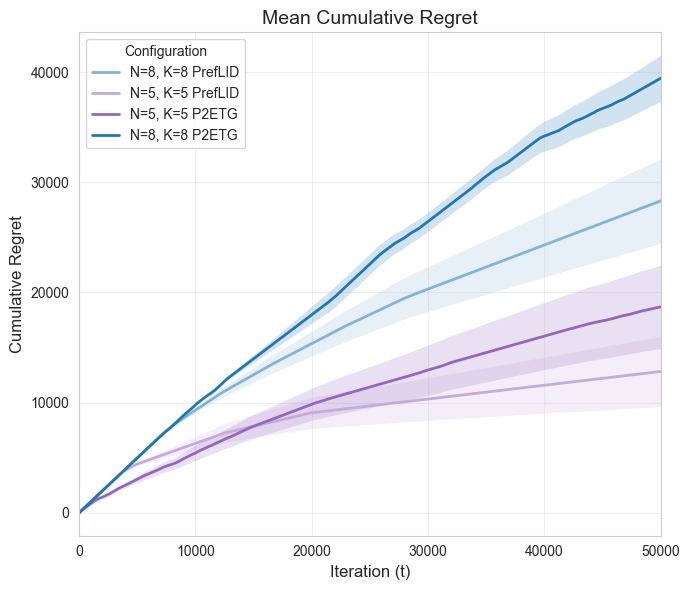

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'Mean Cumulative Regret'}, xlabel='Iteration (t)', ylabel='Cumulative Regret'>)

In [14]:
LABELS = {
    "ver3_P2ETG_N3_K3_a2.0":     "N=3, K=3 P2ETG",
    "ver4_PrefLID_N3_K3_b200000": "N=3, K=3 PrefLID",
    "ver6_P2ETG_N5_K5_a2.0":     "N=5, K=5 P2ETG",
    "ver2_PrefLID_N5_K5_b20000": "N=5, K=5 PrefLID",
    "ver6_P2ETG_N8_K8_a2.0":     "N=8, K=8 P2ETG",
    "ver25_PrefLID_N8_K8_b20000": "N=8, K=8 PrefLID"
}

# Keys = CONFIG NAMES (the all_data keys), values = group name.
COLOR_GROUPS = {
    "N=3, K=3 P2ETG":     "green",
    "N=3, K=3 PrefLID": "green",
    "N=5, K=5 P2ETG":     "purple",
    "N=5, K=5 PrefLID": "purple",
    "N=8, K=8 P2ETG":     "blue",
    "N=8, K=8 PrefLID": "blue"
}

# --- sanity check: do COLOR_GROUPS keys match real config names? ---
print("\nConfig names found:", sorted(all_data.keys()))
print("COLOR_GROUPS keys :", sorted(COLOR_GROUPS.keys()))
missing = [k for k in COLOR_GROUPS if k not in all_data]
if missing:
    print("!! COLOR_GROUPS keys not present in data:", missing)


plot_mean_regret_with_std(
    all_data,
    max_iterations=MAX_ITERATIONS,
    save_path=os.path.join(OUTPUT_DIR, "mean_regret_std.png"),
    show_individual=False,
    std_multiplier=0.2,
    labels=LABELS,
    title="Mean Cumulative Regret",
    figsize=(7, 6),
    color_groups=COLOR_GROUPS,
)

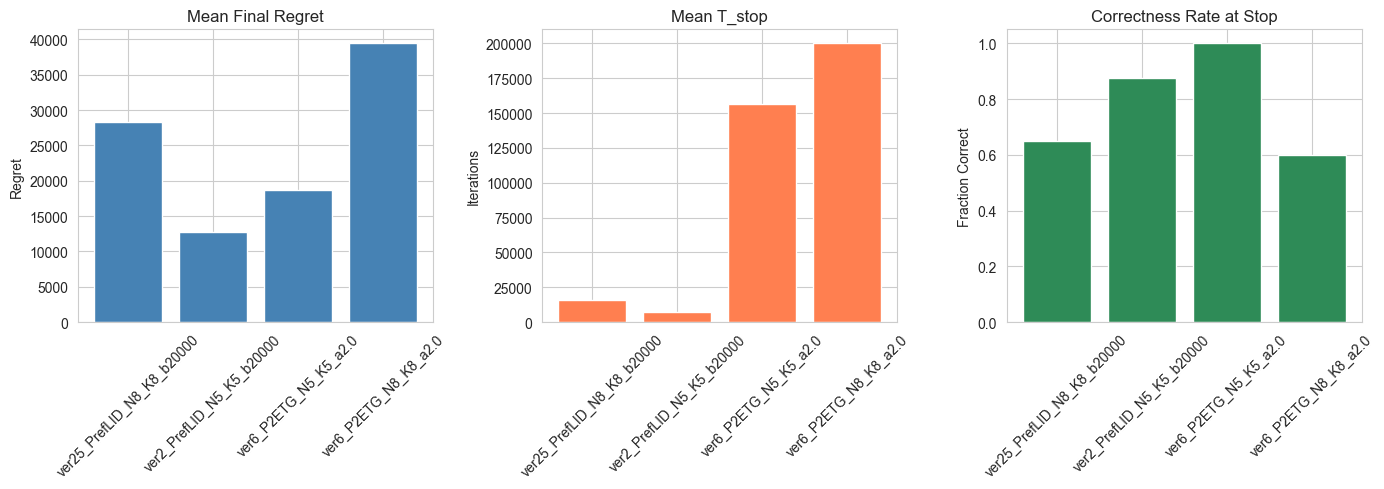

config                  n          T_stop        n_epochs  correct_at_stop    final_regret  stable_under_truth  stable_under_hat  n_stable_matchings      min_bt_gap
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
ver25_PrefLID_N8_K8_b20000   20               -               -               -  80816.400±90296.813               -               -  2.650± 1.631  0.000± 0.000
ver2_PrefLID_N5_K5_b20000    8               -               -               -  31575.000±68143.782               -               -  1.875± 0.991  0.000± 0.000
ver6_P2ETG_N5_K5_a2.0   10  156230.500±63259.759  31246.100±12651.952  1.000± 0.000  27690.000±37725.691               -               -  1.400± 0.516  0.003± 0.004
ver6_P2ETG_N8_K8_a2.0    5  200000.000± 0.000  20000.000± 0.000  0.600± 0.548  93468.000±64788.382               -               -  2.000± 1.000  0.000± 0.000


In [13]:
# ---- Plot 3: bar summaries ----
plot_summary_stats(all_data)

# ---- Summary.json averages ----
df  = collect_summaries(BASE_DIR)
avg = average_summaries(df, by="config")

print_summary_table(avg, fields=[
    "T_stop", "n_epochs", "correct_at_stop",
    "final_regret", "stable_under_truth", "stable_under_hat",
    "n_stable_matchings", "min_bt_gap",
])